In [ ]:
import numpy as np
import scipy as sp
import csv
#import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d as smooth
from scipy.stats import wasserstein_distance as wd
from scipy.interpolate import UnivariateSpline as Uspline

import math
import numba
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_normal_float32
#import cupy as cp

host_seed = 42

from google.colab import drive
drive.mount("/content/drive")


base_dir = "/content/drive/My Drive/MSci Maths/Cleaned Data"
fig_dir = "/content/drive/My Drive/MSci Maths/Figures"

Mounted at /content/drive


In [ ]:
widths = [3, 4, 5, 6, 8, 10] # Exclude w=2!
CaArr = [0.05, 0.1, 0.2, 0.4, 0.8]
uIDs = [i for i in range(1, 40)]

# Load data

In [ ]:
raw_histograms = {}

for w in widths:
  for Ca in CaArr:
    read_path = base_dir + f"/PDFs/PDFs by (w, Ca) 4096 bins raw/Double4r/pdf_w{w}_Ca{Ca}.npz"
    subset = np.load(read_path)

    density = subset["density"]
    bin_edges = subset["bin_edges"]
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    raw_histograms[(w, Ca)] = {
        "density": density,
        "bin_centres": bin_centres,
        "bin_edges": bin_edges}

In [ ]:
smooth_histograms = {}

for w in widths:
  for Ca in CaArr:
    read_path = base_dir + f"/PDFs/PDFs by (w, Ca) 4096 bins Gaussian smoothed/50_sigma_bins/Double50s/pdf_w{w}_Ca{Ca}.npz"
    subset = np.load(read_path)

    density = subset["density"]
    bin_edges = subset["bin_edges"]
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    smooth_histograms[(w, Ca)] = {
        "density": density,
        "bin_centres": bin_centres,
        "bin_edges": bin_edges}

# Initialising

## Preliminary graph

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-610277846.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.suptitle("50$\sigma$ bandwidth smoothing", y=0.98, fontsize=18)


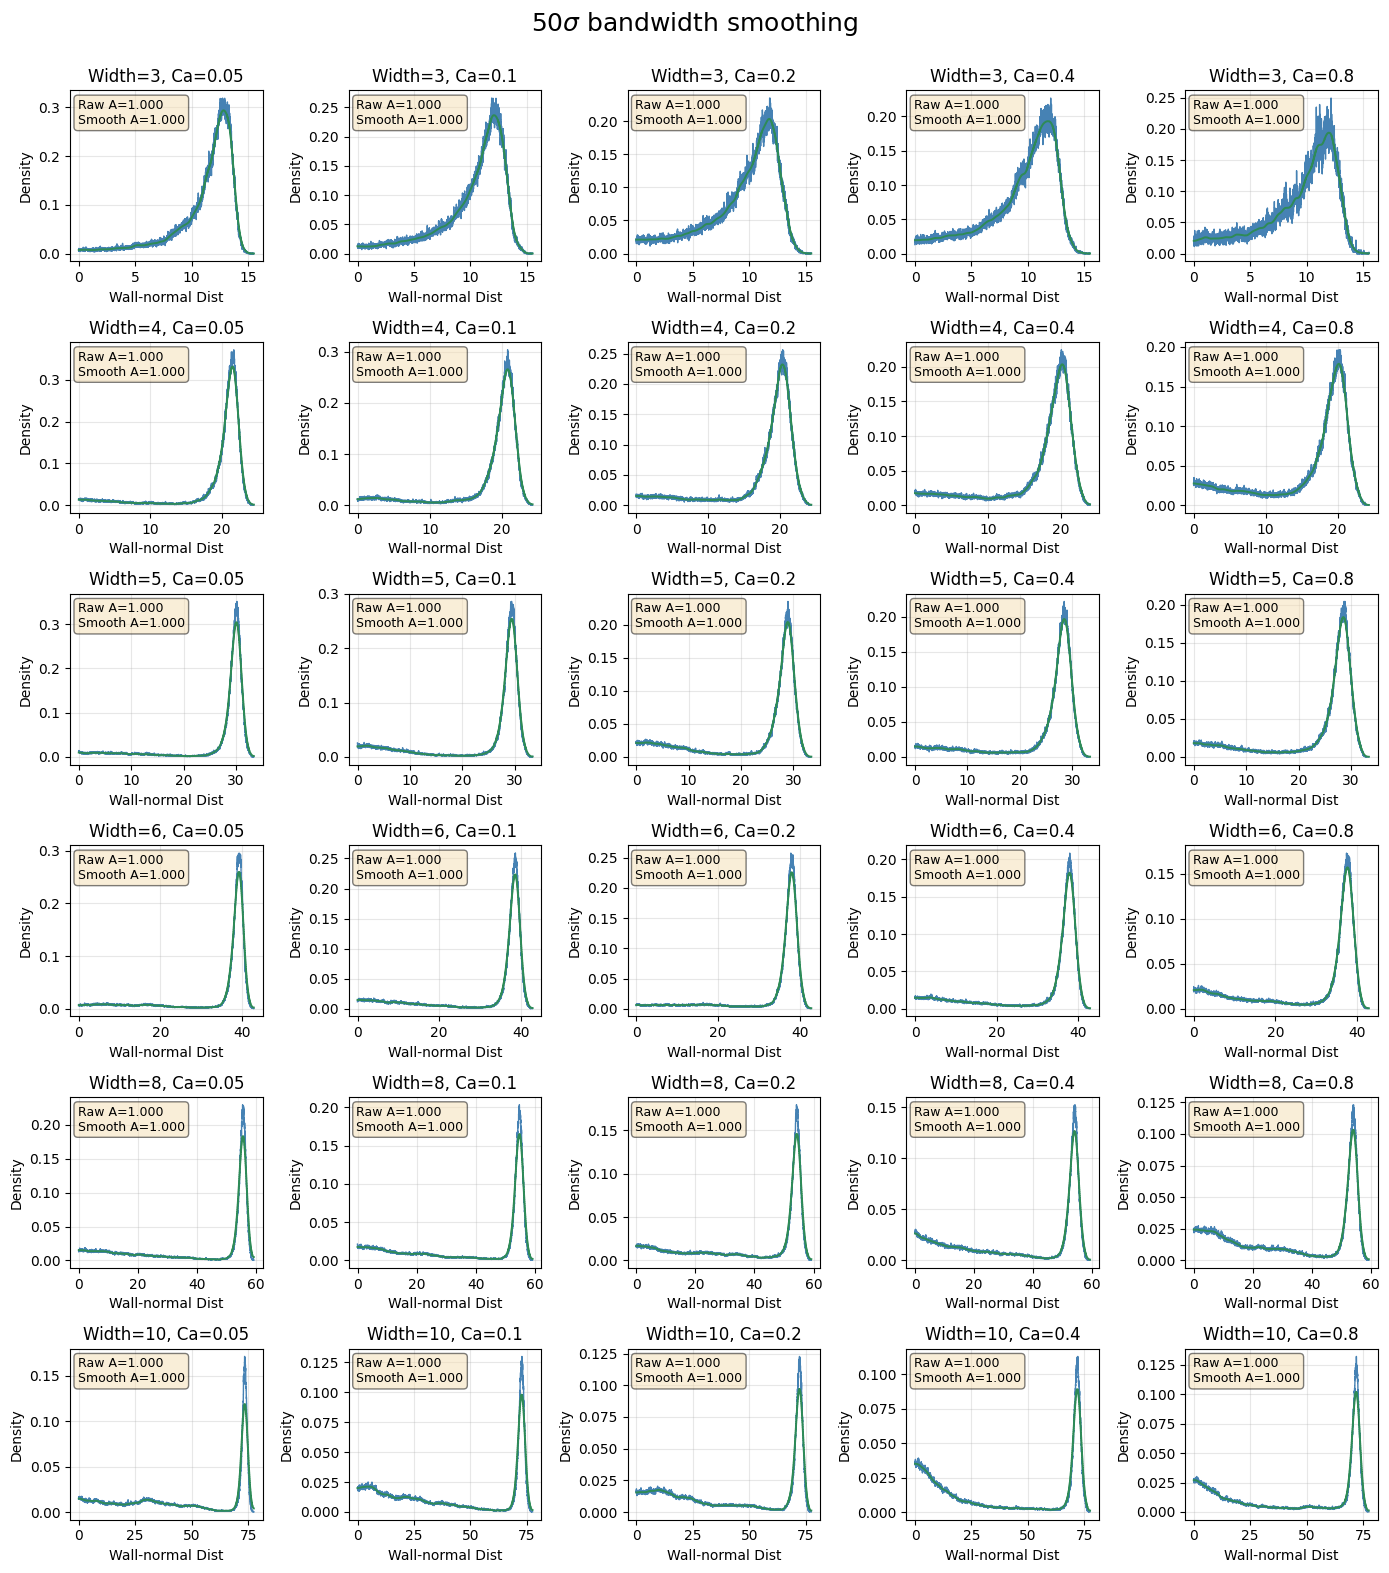

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False
)

fig_name = "50s_vs_raw_collapsed"

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset_raw = raw_histograms[key]
    subset_smooth = smooth_histograms[key]

    # Plotting
    ax.plot(subset_raw["bin_centres"], subset_raw["density"],
            drawstyle="steps-mid", lw=1.0, color="steelblue")
    ax.plot(subset_smooth["bin_centres"], subset_smooth["density"],
            drawstyle="steps-mid", lw=1.4, color="seagreen")

    ax.set_title(f"Width={w}, Ca={Ca}")
    ax.set_xlabel('Wall-normal Dist')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

    x_align=0.97 if w==2 else 0.04
    h_align="right" if w==2 else "left"
    stats_text = (f"Raw A={np.sum(subset_raw["density"] * np.diff(subset_raw["bin_edges"])):.3f}\n"
                  f"Smooth A={np.sum(subset_smooth["density"] * np.diff(subset_smooth["bin_edges"])):.3f}")
    ax.text(x_align, 0.95, stats_text, transform=ax.transAxes,
            horizontalalignment=h_align, verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("50$\sigma$ bandwidth smoothing", y=0.98, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, .98])
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

## Reconstruct pdfs

In [ ]:
recon_pdfs = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = smooth_histograms[key]

    density = subset["density"]
    bin_centres = subset["bin_centres"]

    neg_density = density[1:][::-1]
    neg_bin_centres = -bin_centres[1:][::-1]

    new_density = np.concatenate([neg_density, density])
    new_centres = np.concatenate([neg_bin_centres, bin_centres])

    dx = bin_centres[1] - bin_centres[0]
    new_density /= np.sum(new_density) * dx

    recon_pdfs[key] = {
        "density": new_density,
        "bin_centres": new_centres}

In [ ]:
recon_pdfs_raw = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = raw_histograms[key]

    density = subset["density"]
    bin_centres = subset["bin_centres"]

    neg_density = density[1:][::-1]
    neg_bin_centres = -bin_centres[1:][::-1]

    new_density = np.concatenate([neg_density, density])
    new_centres = np.concatenate([neg_bin_centres, bin_centres])

    dx = bin_centres[1] - bin_centres[0]
    new_density /= np.sum(new_density) * dx

    recon_pdfs_raw[key] = {
        "density": new_density,
        "bin_centres": new_centres}

## Implied potential construction

In [ ]:
def V_from_pdf(p):
  V = -np.log(p + 1e-12 * np.max(p))
  #V -= V.min()
  return V

def Force_from_V(V, dx):
  return np.gradient(V, dx)

In [ ]:
tables = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = recon_pdfs[key]

    density = subset["density"]
    x = subset["bin_centres"]

    dx = x[1] - x[0]
    V = V_from_pdf(density)
    F = Force_from_V(V, dx)

    tables[key] = {
        "x": x,
        "dx": dx,
        "V": V,
        "F": F
    }

In [ ]:
tables_raw = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = recon_pdfs_raw[key]

    density = subset["density"]
    x = subset["bin_centres"]

    dx = x[1] - x[0]
    V = V_from_pdf(density)
    F = Force_from_V(V, dx)

    tables_raw[key] = {
        "x": x,
        "dx": dx,
        "V": V,
        "F": F
    }

## Smoothed potential plot

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2272034956.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.suptitle("50$\sigma$-smoothed potential and force", y=0.98, fontsize=18)


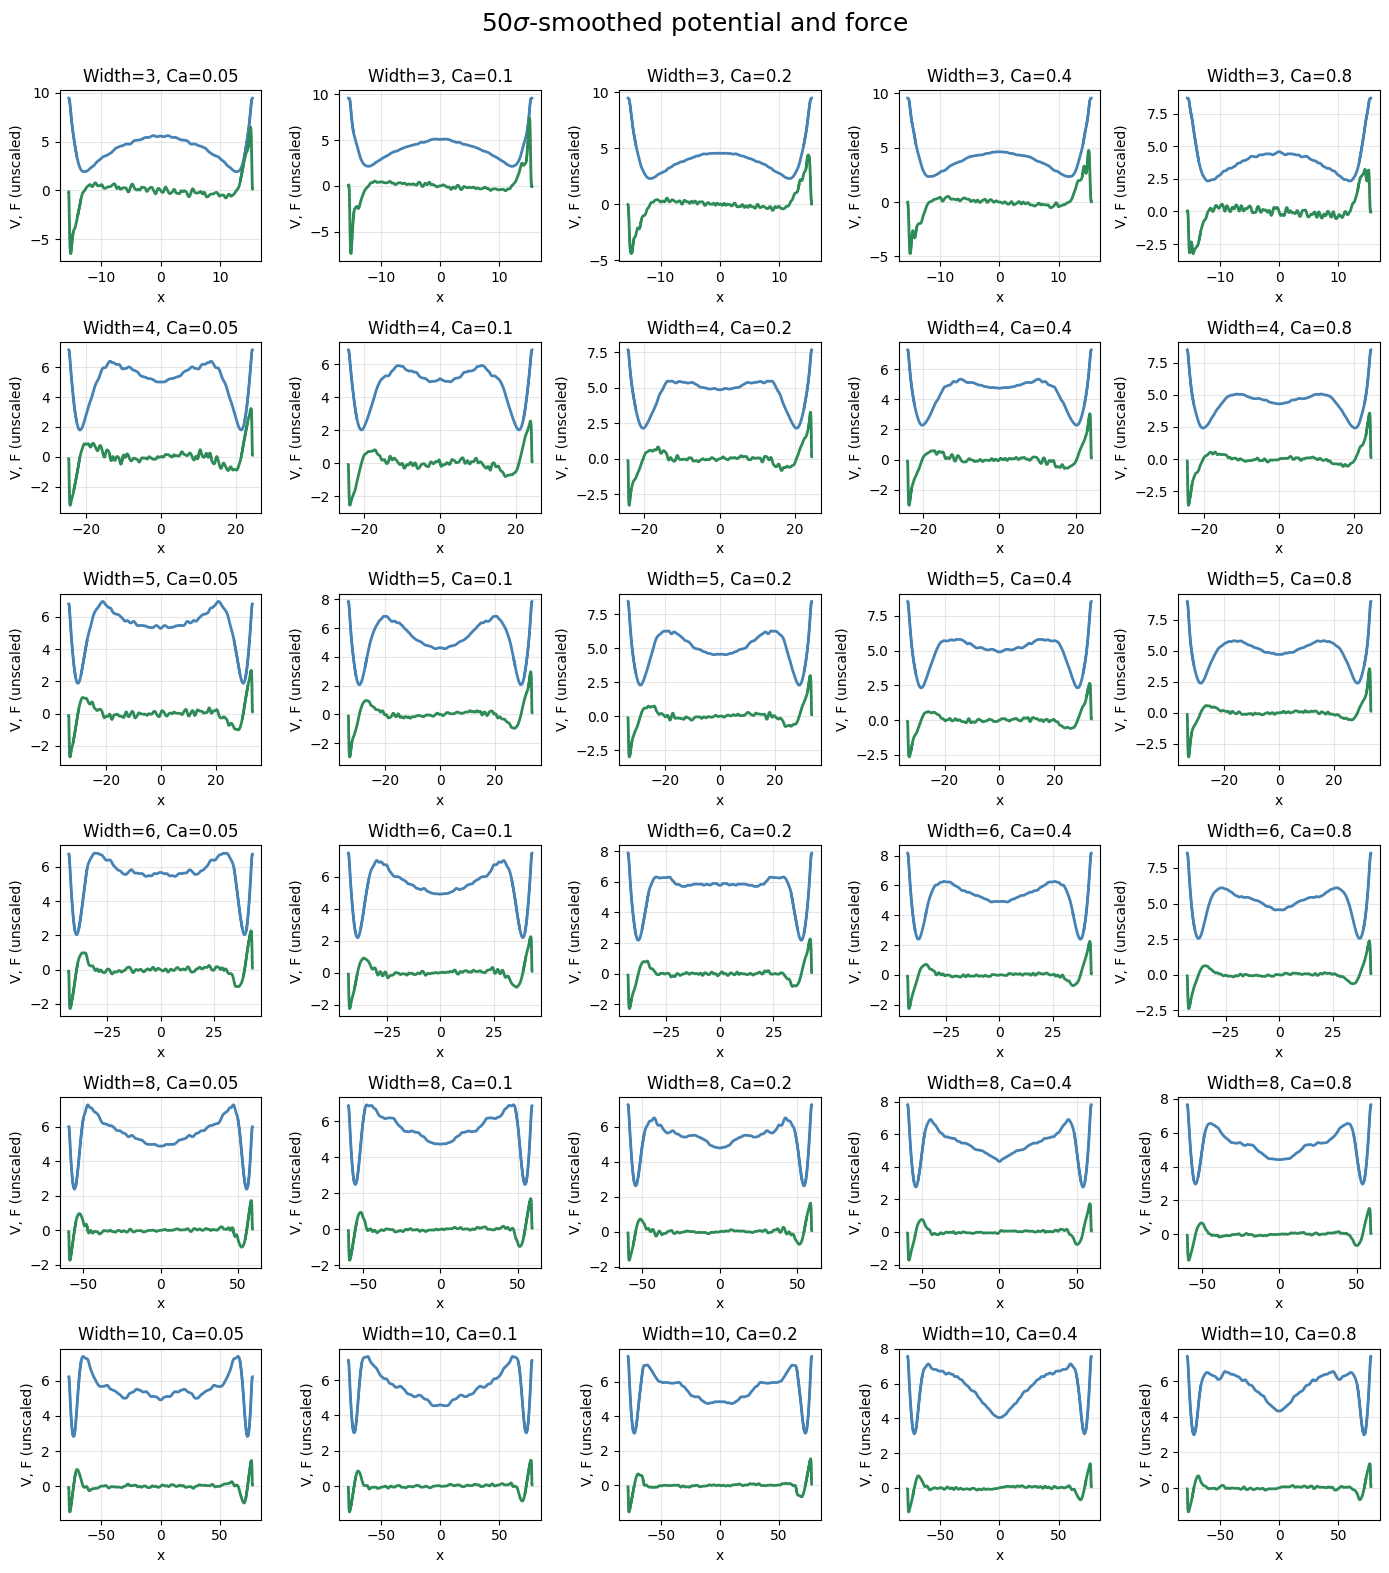

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False
)

fig_name = "50s_VnF_reconstructed"

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset = tables[key]

    x = subset["x"]
    V = subset["V"]
    F = subset["F"]
    dx = subset["dx"]


    # Plotting
    ax.plot(x, V, drawstyle="steps-mid", lw=2., color="steelblue", label="V(x)")
    ax.plot(x, F, drawstyle="steps-mid", lw=2.0, color="seagreen", label="F(x)")

    ax.set_title(f"Width={w}, Ca={Ca}")
    ax.set_xlabel('x')
    ax.set_ylabel('V, F (unscaled)')
    ax.grid(True, alpha=0.3)

    y_align=0.12

    #stats_text = f"Lorem ipsum"
    #ax.text(0.5, y_align, stats_text, transform=ax.transAxes,
    #        horizontalalignment="center", verticalalignment="top", fontsize=9,
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("50$\sigma$-smoothed potential and force", y=0.98, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, .98])
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

FORCE IS STILL SO NOISY DESPITE STRONG SMOOTHING - HAVE TO SPLINE.

# Spline Approximations

In [ ]:
def spline_potential(x, V, smooth_factor=None, joints=3):
    spline = Uspline(x, V, s=smooth_factor, k=joints)
    return spline

In [ ]:
tables_spline = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = tables[key]

    V = subset["V"]
    x = subset["x"]
    dx = subset["dx"]

    j = 3 if w==3 else 3
    spline = spline_potential(x, V, smooth_factor=0.007 * len(x), joints=j)

    V_smooth = spline(x)
    V_sym = 0.5 * (V_smooth + V_smooth[::-1])
    #F_smooth = spline.derivative()(x)
    F_sym = np.gradient(V_sym, x)

    tables_spline[key] = {
        "x": x,
        "dx": dx,
        "V": V_sym,
        "F": F_sym}

## Graph spline approx

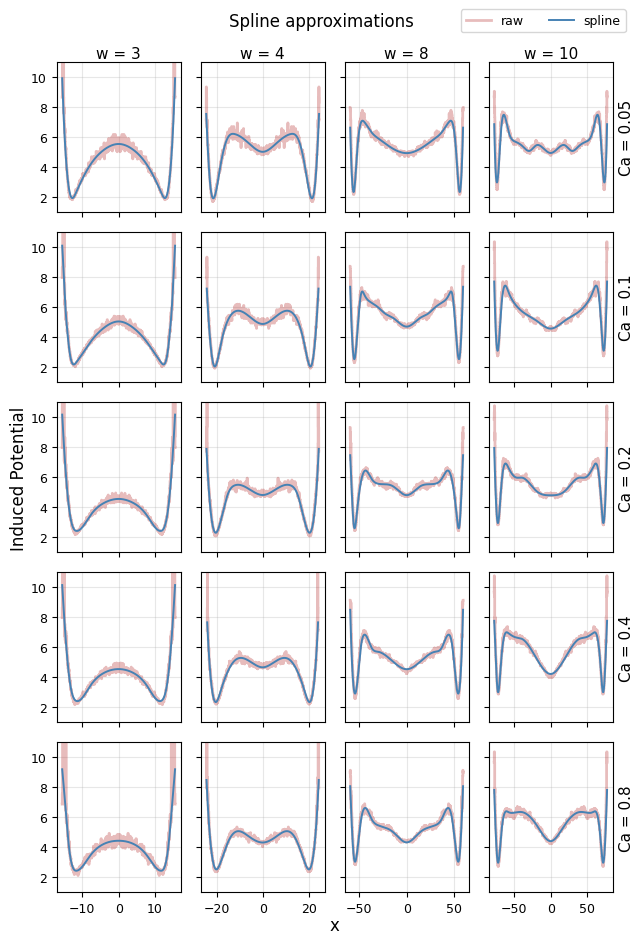

In [ ]:
fig, axes = plt.subplots(
    nrows = len(CaArr),
    ncols = len([3, 4, 8, 10]),
    figsize = (6.76, 9.7),
    sharex="col",
    sharey=True
)

step=10

for i, w in enumerate([3, 4, 8, 10]):
  for j, Ca in enumerate(CaArr):
    ax = axes[j, i]
    key = (w, Ca)

    subset_spline = tables_spline[key]
    subset_smooth = tables[key]
    subset_raw = tables_raw[key]

    x = subset_smooth["x"]
    dx = subset_smooth["dx"]

    V_raw = subset_raw["V"]
    V_smooth = subset_smooth["V"]
    V_spline = subset_spline["V"]


    # Plotting
    if i==0 and j==0:
      ax.plot(x[::step], V_raw[::step], drawstyle="steps-mid", lw=2.0, color="firebrick",
              alpha=0.3, label="raw")
      #ax.plot(x, V_smooth, drawstyle="steps-mid", lw=2.0, color="seagreen")
      ax.plot(x, V_spline, lw=1.4, color="steelblue", label="spline")
    else:
      ax.plot(x[::step], V_raw[::step], drawstyle="steps-mid", lw=2.0, color="firebrick", alpha=0.3)
      #ax.plot(x, V_smooth, drawstyle="steps-mid", lw=2.0, color="seagreen")
      ax.plot(x, V_spline, lw=1.4, color="steelblue")

    #ax.set_title(f"Width={w}, Ca={Ca}")
    #ax.set_xlabel('x')
    #ax.set_ylabel('')
    ax.set_ylim(1, 11)
    ax.grid(True, alpha=0.3)
    axes[0, i].set_title(f"w = {w}", pad=3)
    axes[j, -1].set_ylabel(f"Ca = {Ca}", rotation=90, labelpad=-108,
                          fontsize=plt.rcParams["axes.titlesize"])

fig.supxlabel("x", y=0.03, x=1.04/2)
fig.supylabel("Induced Potential", x=0.04)
fig.legend(ncols=2, loc="upper right", bbox_to_anchor=(0.96, 0.99))

plt.suptitle("Spline approximations")
plt.tight_layout(rect=[0, 0, 1, .995])
fig_name = "spline_vs_raw_potentials"
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

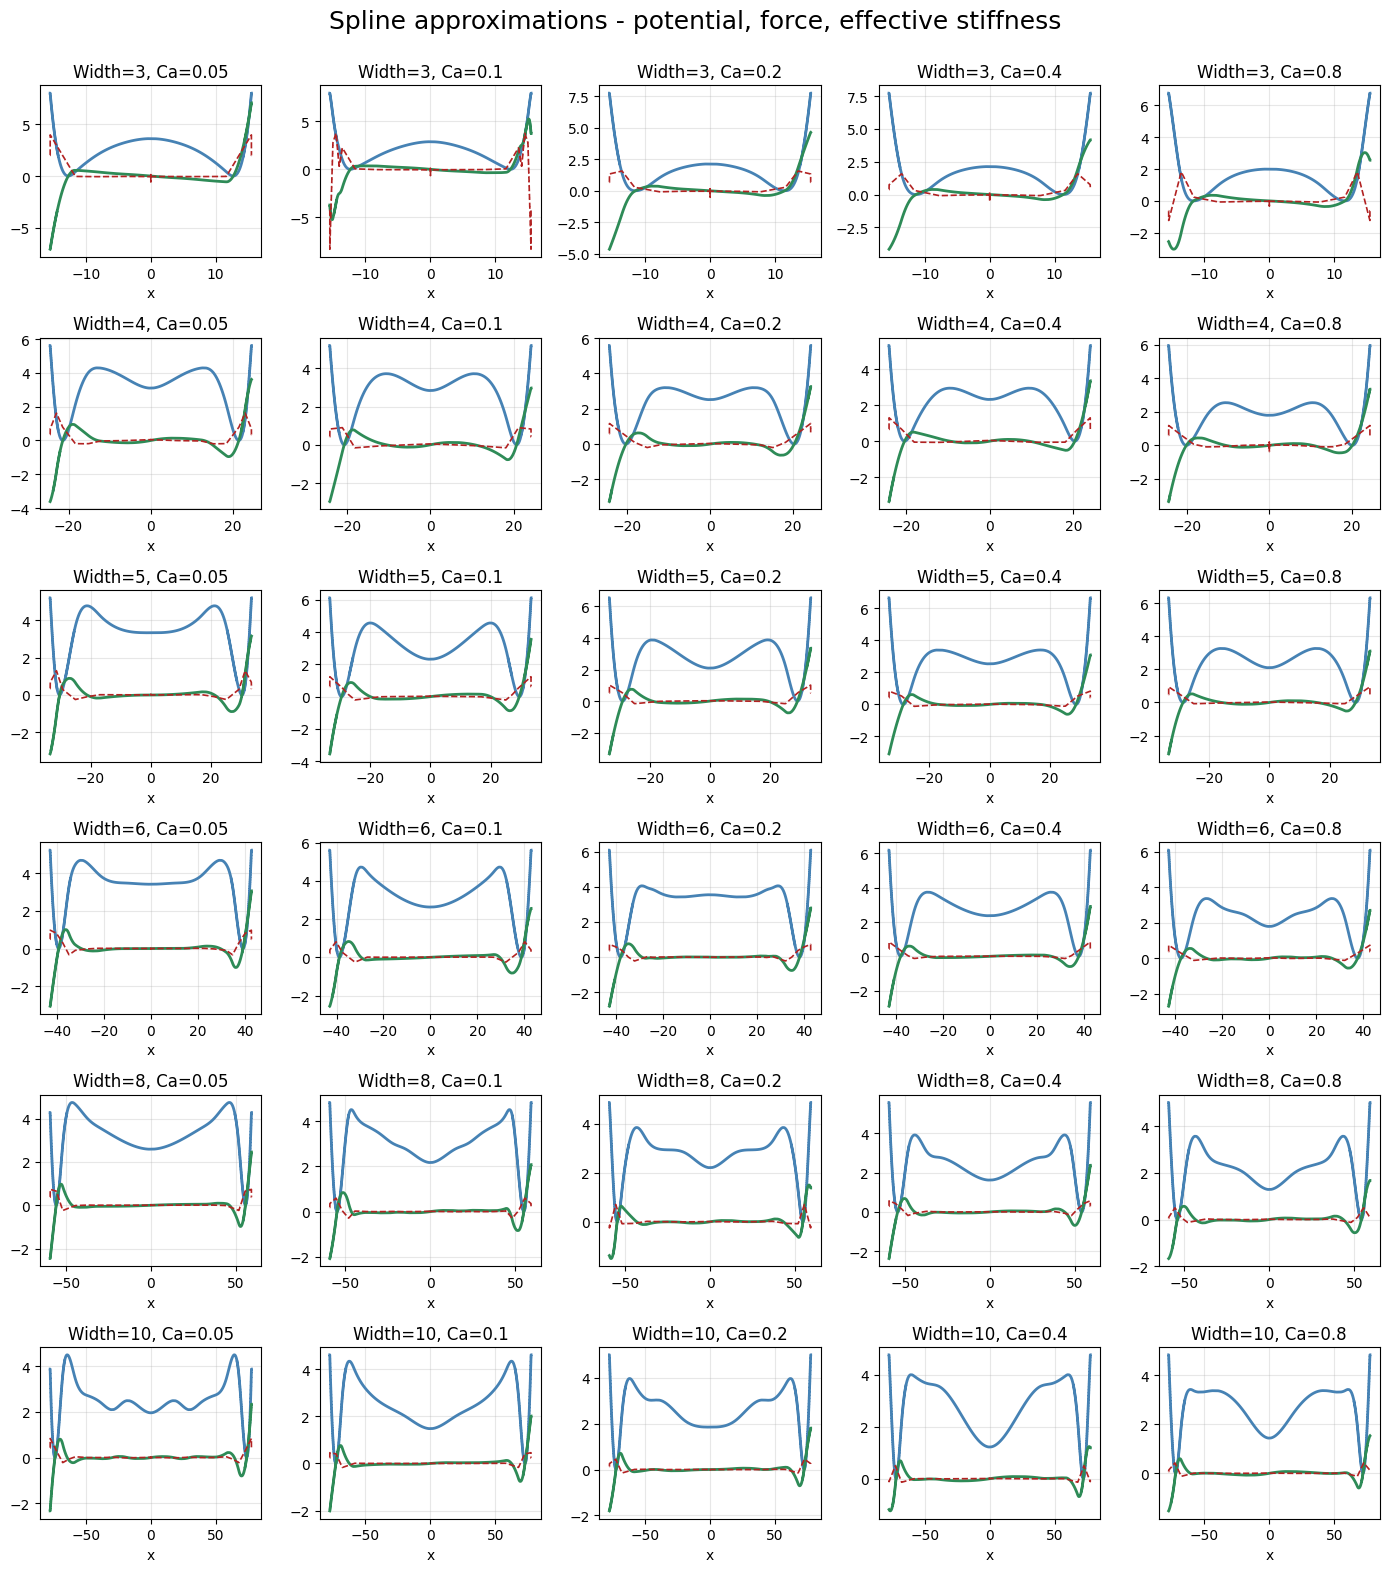

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False
)

fig_name = "spline_VnFnS"

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset = tables_spline[key]

    x = subset["x"]
    V = subset["V"]
    V = V - V.min()
    F = subset["F"]
    S = np.gradient(F, x)
    dx = subset["dx"]


    # Plotting
    ax.plot(x, V, drawstyle="steps-mid", lw=2., color="steelblue", label="V(x)")
    ax.plot(x, F, drawstyle="steps-mid", lw=2., color="seagreen", label="F(x)")
    ax.plot(x, S, drawstyle="steps-mid", lw=1.2, color="firebrick",
            linestyle="--", label="S(x)", alpha = 1.0)

    ax.set_title(f"Width={w}, Ca={Ca}")
    ax.set_xlabel('x')
    #ax.legend()
    ax.grid(True, alpha=0.3)

    y_align=0.12

    #stats_text = f"Lorem ipsum"
    #ax.text(0.5, y_align, stats_text, transform=ax.transAxes,
    #        horizontalalignment="center", verticalalignment="top", fontsize=9,
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Spline approximations - potential, force, effective stiffness", y=0.98, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, .98])
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

In [ ]:
def implied_pdf_from_V_eps(V, x, eps=1.0):
  dx = x[1] - x[0]
  p = np.exp(-V / eps)
  p /= np.sum(p) * dx
  return p

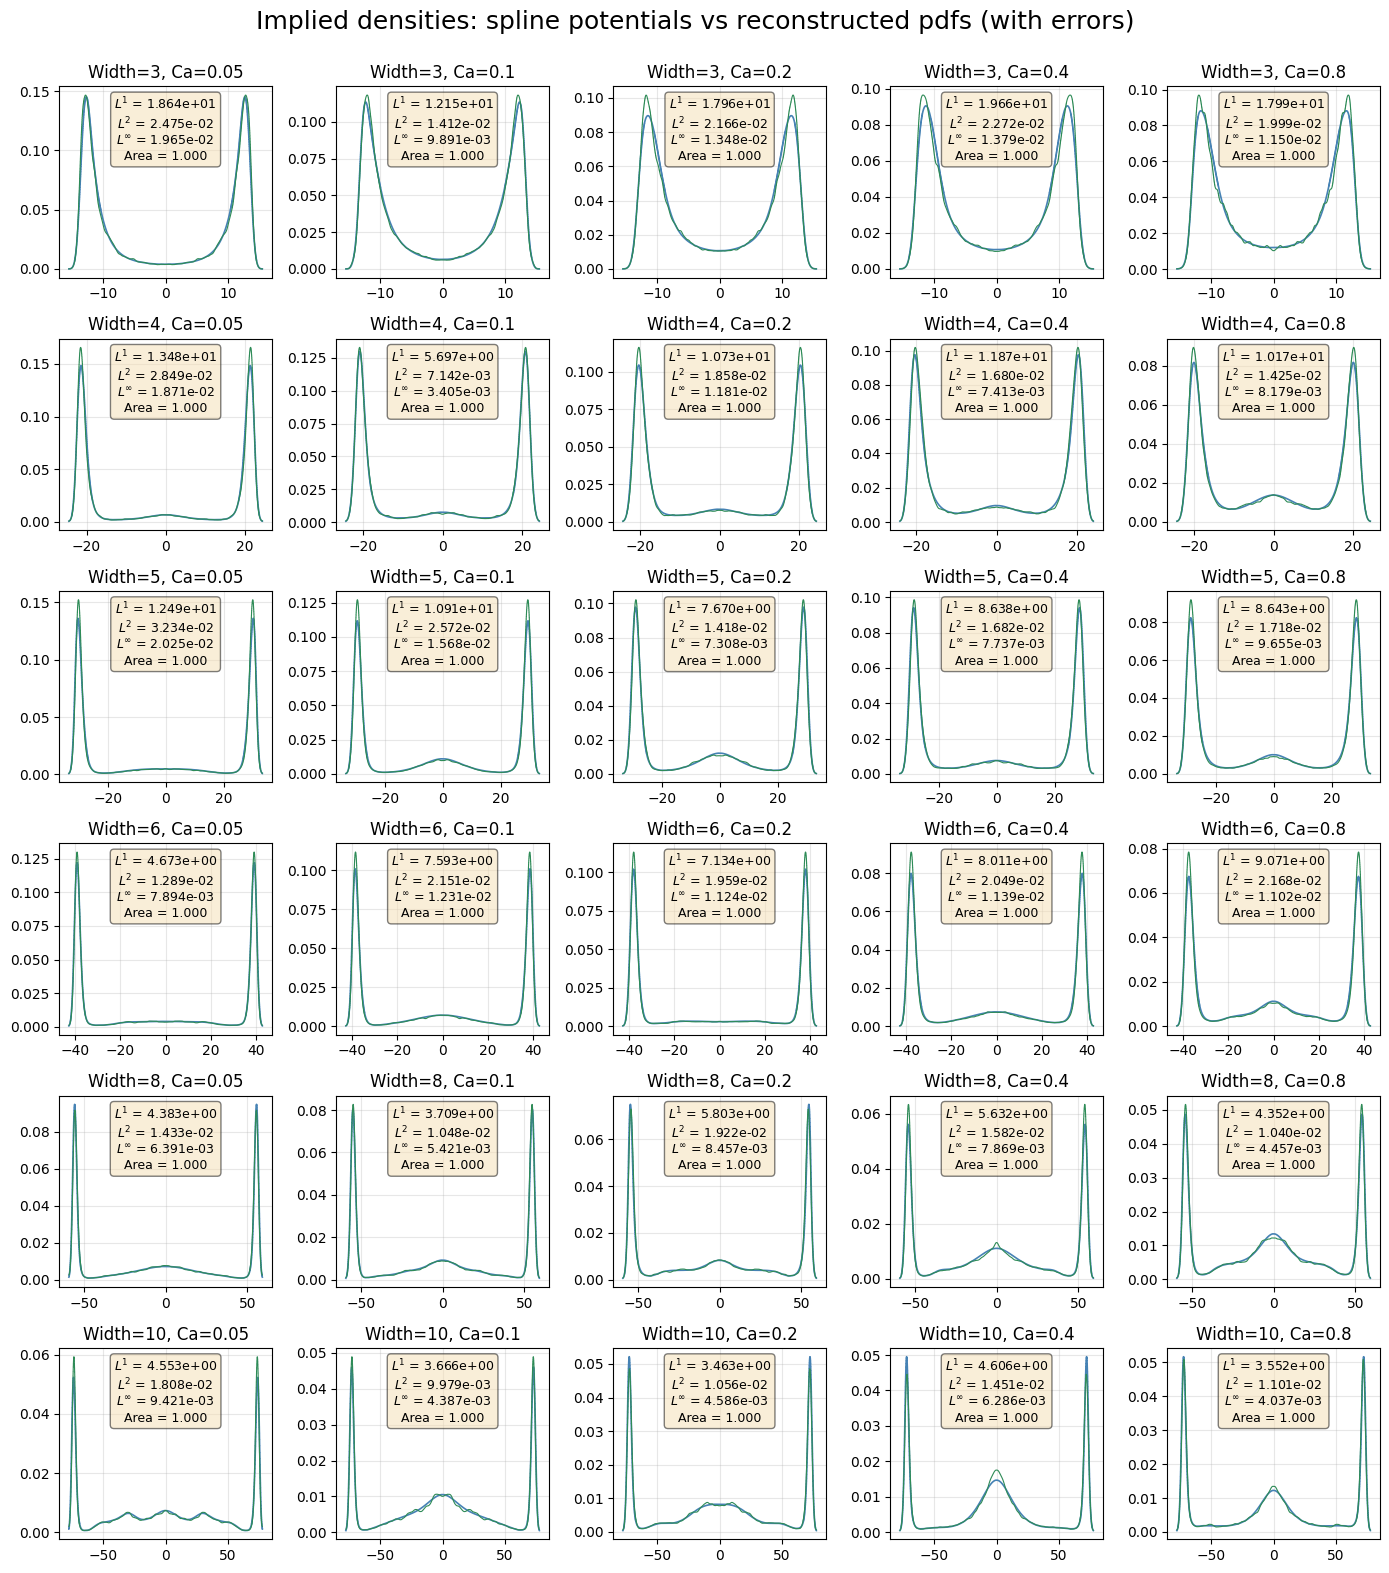

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False)

fig_name = "spline_pdf_vs_smoothed_pdf"

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset = tables_spline[key]
    subset_old = recon_pdfs[key]

    old_dens = subset_old["density"]
    x = subset["x"]
    V = subset["V"]
    density = implied_pdf_from_V_eps(V, x)


    # Plotting
    ax.plot(x, density, drawstyle="steps-mid", lw=1.2,
            color="steelblue", label="V,p-smoothed")
    ax.plot(x, old_dens, drawstyle="steps-mid", lw=0.8,
            color="seagreen", label="p-smoothed")
    #ax.plot(x, np.abs(density-old_dens), drawstyle="steps-mid",
    #        linestyle="--", color="r", label="difference", alpha=0.5)

    ax.set_title(f"Width={w}, Ca={Ca}")
    #ax.set_xlabel('x')
    #ax.set_ylabel('')
    ax.grid(True, alpha=0.3)

    # Stats
    dx = x[1] - x[0]
    L1 = np.sum(np.abs(density - old_dens))
    L2 = np.sqrt(np.sum((density - old_dens)**2) * dx)
    Linf = np.max(np.abs(density - old_dens))
    stats_text = (
        f"$L^1$ = {L1:.3e}\n"
        f"$L^2$ = {L2:.3e}\n"
        f"$L^\\infty$ = {Linf:.3e}\n"
        f"Area = {np.sum(density * dx):.3f}")

    y_align=0.95
    ax.text(0.5, y_align, stats_text, transform=ax.transAxes,
            horizontalalignment="center", verticalalignment="top", fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Implied densities: spline potentials vs reconstructed pdfs (with errors)", y=0.98, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, .98])
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

## Minimising Wasserstein Loss

In [ ]:
def pdf_loss_wasserstein(x, p_model, p_raw):
  p_model = p_model / np.sum(p_model) # Rescale just in case
  p_raw   = p_raw   / np.sum(p_raw)
  return wd(x, x, u_weights=p_model, v_weights=p_raw)

def implied_pdf_from_V_eps(V, x, eps=1.0):
  dx = x[1] - x[0]
  p = np.exp(-V / eps)
  p /= np.sum(p) * dx
  return p

In [ ]:
def fit_eps_Vspline_wasserstein(x, Vspline, p_raw, eps_grid):
  losses = []

  for eps in eps_grid:
    p_spline = implied_pdf_from_V_eps(Vspline, x, eps)
    loss = pdf_loss_wasserstein(x, p_spline, p_raw)
    losses.append(loss)

  losses = np.array(losses)
  eps_opt = eps_grid[np.argmin(losses)]

  return losses, eps_opt

### Optimal epsilon choice plot

In [ ]:
key = (6, 0.4)
eps_grid = np.linspace(0.1, 3, 3100)

subset = tables_spline[key]
V = subset["V"]
x = subset["x"]

p_raw = recon_pdfs_raw[key]["density"]

losses, eps_opt_w = fit_eps_Vspline_wasserstein(x, V, p_raw, eps_grid)

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-294747502.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(p_spline_opt, lw=1.4, color="steelblue", label=f"$\epsilon=${eps_opt_w:.3f}")


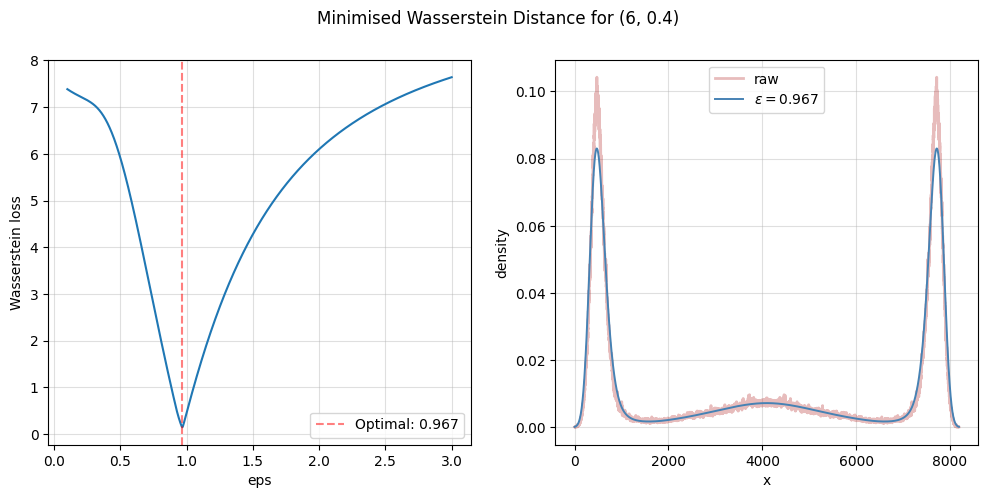

Optimal epsilon choice: 0.9674733785091965


In [ ]:
eps_c = 0.85
x = recon_pdfs_raw[key]["bin_centres"]
p_raw = recon_pdfs_raw[key]["density"]
V_spline = tables_spline[key]["V"]
p_spline_opt = implied_pdf_from_V_eps(V, x, eps_opt_w)
p_spline_eps = implied_pdf_from_V_eps(V, x, eps_c)

plt.figure(figsize=(12,5))
fig_name = "eps_wass_fit_w6_Ca0.4"

plt.subplot(1,2,1)
plt.plot(eps_grid, losses)
plt.axvline(eps_opt_w, color="r", linestyle="--", alpha=0.5, label=f"Optimal: {eps_opt_w:.3f}")
plt.xlabel("eps")
plt.ylabel("Wasserstein loss")
plt.legend()
plt.grid(alpha=0.4)

plt.subplot(1,2,2)
plt.plot(p_raw, lw=2.0, color="firebrick", label="raw",alpha=0.3)
plt.plot(p_spline_opt, lw=1.4, color="steelblue", label=f"$\epsilon=${eps_opt_w:.3f}")
#plt.plot(p_spline_eps, lw=1.4, color="steelblue", label=f"eps: {eps_c}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.4)

plt.suptitle(f"Minimised Wasserstein Distance for {key}")
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

print(f"Optimal epsilon choice: {eps_opt_w}")

Not the most optimal in preserving peaks; clearly...

# Fitting epsilon with different loss functions

## Testing on (6, 0.4)

In [ ]:
def loss_L1(x, p_model, p_raw):
  dx = x[1] - x[0]
  return np.sum(np.abs(p_model - p_raw)) * dx

def loss_L2(x, p_model, p_raw):
  dx = x[1] - x[0]
  return np.sum((p_model - p_raw)**2) * dx

def loss_logL2(x, p_model, p_raw):
  dx = x[1] - x[0]
  a = np.log(p_model + 1e-12 * np.max(p_model))
  b = np.log(p_raw + 1e-12 * np.max(p_raw))
  return np.sum((a - b)**2) * dx

def loss_Linf(x, p_model, p_raw):
  dx = x[1] - x[0]
  return np.max(np.abs(p_model - p_raw))

def fit_eps_Vspline_by_loss(x, Vspline, p_raw, eps_grid, loss_fn):
  dx = x[1] - x[0]
  p_raw = p_raw / (np.sum(p_raw) * dx) # just making sure
  losses = np.empty_like(eps_grid, dtype=np.float64)

  for k, eps in enumerate(eps_grid):
    p_model = implied_pdf_from_V_eps(Vspline, x, eps)
    losses[k] = loss_fn(x, p_model, p_raw)

  eps_opt = eps_grid[np.argmin(losses)]
  return losses, eps_opt

In [ ]:
key = (6, 0.4)
eps_c = 0.85
eps_grid = np.linspace(0.1, 3, 200)

x = recon_pdfs_raw[key]["bin_centres"]
p_raw = recon_pdfs_raw[key]["density"]
V = tables_spline[key]["V"]

p_spline_eps = implied_pdf_from_V_eps(V, x, eps_c)

## $L^1-\text{norm}$

In [ ]:
losses, eps_opt_L1 = fit_eps_Vspline_by_loss(x, V, p_raw, eps_grid, loss_L1)
p_spline_opt = implied_pdf_from_V_eps(V, x, eps_opt_L1)

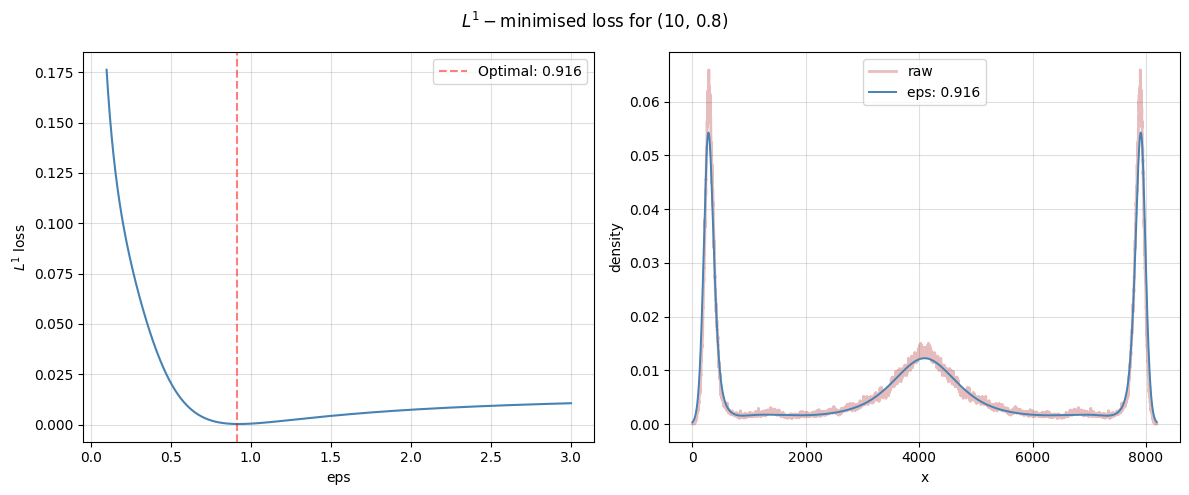

In [ ]:
plt.figure(figsize=(12, 5))
fig_name = "eps_L1_fit_w6_Ca0.4"

plt.subplot(1,2,1)
plt.plot(eps_grid, losses, color="steelblue")
plt.axvline(eps_opt_L1, color="r", linestyle="--", alpha=0.5, label=f"Optimal: {eps_opt_L1:.3f}")
plt.xlabel("eps")
plt.ylabel("$L^1$ loss")
plt.legend()
plt.grid(alpha=0.4)

plt.subplot(1,2,2)
plt.plot(p_raw, lw=2.0, color="firebrick", label="raw",alpha=0.3)
plt.plot(p_spline_opt, lw=1.4, color="steelblue", label=f"eps: {eps_opt_L1:.3f}")
#plt.plot(p_spline_eps, lw=1.4, color="steelblue", label=f"eps: {eps_c}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.4)

plt.suptitle(f"$L^1-$minimised loss for {key}")
plt.tight_layout()
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

## $L^2-\text{norm}$

In [ ]:
losses, eps_opt_L2 = fit_eps_Vspline_by_loss(x, V, p_raw, eps_grid, loss_L2)
p_spline_opt = implied_pdf_from_V_eps(V, x, eps_opt_L2)

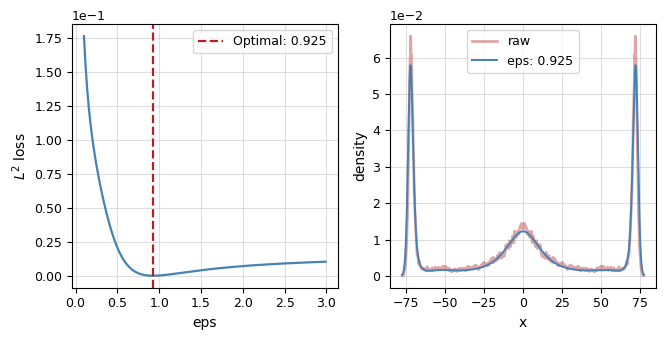

In [ ]:
plt.figure(figsize=(6.76, 3.5))

step=10
x = tables_spline[key]["x"]

plt.subplot(1,2,1)
plt.plot(eps_grid[::step], losses[::step], color="steelblue")
plt.axvline(eps_opt_L2, color="firebrick", linestyle="--", label=f"Optimal: {eps_opt_L2:.3f}")
plt.xlabel("eps")
plt.ylabel("$L^2$ loss")
plt.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
plt.legend()
plt.grid(alpha=0.4)

plt.subplot(1,2,2)
plt.plot(x[::step], p_raw[::step], lw=2.0, color="firebrick", label="raw",alpha=0.4)
plt.plot(x, p_spline_opt, lw=1.4, color="steelblue", label=f"eps: {eps_opt_L2:.3f}")
#plt.plot(p_spline_eps, lw=1.4, color="steelblue", label=f"eps: {eps_c}")
plt.xlabel("x")
plt.ylabel("density")
plt.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
plt.legend()
plt.grid(alpha=0.4)

#plt.suptitle(f"$L^2-$minimised loss for {key}")
plt.tight_layout()
fig_name = f"eps_L2_fit_w{key[0]}_Ca{key[1]}"
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

## $L^\infty -\text{norm}$

In [ ]:
losses, eps_opt_Linf = fit_eps_Vspline_by_loss(x, V, p_raw, eps_grid, loss_Linf)
p_spline_opt = implied_pdf_from_V_eps(V, x, eps_opt_Linf)

<>:8: SyntaxWarning: invalid escape sequence '\L'
<>:21: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\L'
<>:21: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipython-input-1268529160.py:8: SyntaxWarning: invalid escape sequence '\L'
  plt.ylabel("$\L^\infty$ loss")
/tmp/ipython-input-1268529160.py:21: SyntaxWarning: invalid escape sequence '\i'
  plt.suptitle(f"$L^\infty-$minimised loss for {key}")


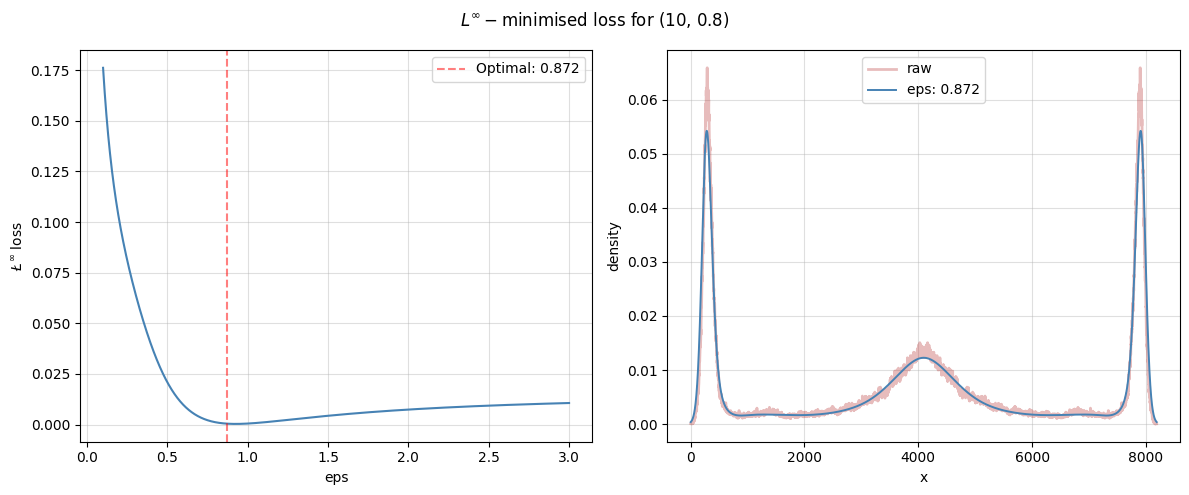

In [ ]:
plt.figure(figsize=(12, 5))
fig_name = "eps_Linf_fit_w6_Ca0.4"

plt.subplot(1,2,1)
plt.plot(eps_grid, losses, color="steelblue")
plt.axvline(eps_opt_Linf, color="r", linestyle="--", alpha=0.5, label=f"Optimal: {eps_opt_Linf:.3f}")
plt.xlabel("eps")
plt.ylabel("$\L^\infty$ loss")
plt.legend()
plt.grid(alpha=0.4)

plt.subplot(1,2,2)
plt.plot(p_raw, lw=2.0, color="firebrick", label="raw",alpha=0.3)
plt.plot(p_spline_opt, lw=1.4, color="steelblue", label=f"eps: {eps_opt_Linf:.3f}")
#plt.plot(p_spline_eps, lw=1.4, color="steelblue", label=f"eps: {eps_c}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.4)

plt.suptitle(f"$L^\infty-$minimised loss for {key}")
plt.tight_layout()
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

## $\log L^2-\text{norm}$

In [ ]:
losses, eps_opt_logL2 = fit_eps_Vspline_by_loss(x, V, p_raw, eps_grid, loss_logL2)
p_spline_opt = implied_pdf_from_V_eps(V, x, eps_opt_logL2)

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2214115389.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\log L^2$ loss")
/tmp/ipython-input-2214115389.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.suptitle(f"$\log L^2-$minimised loss for {key}")


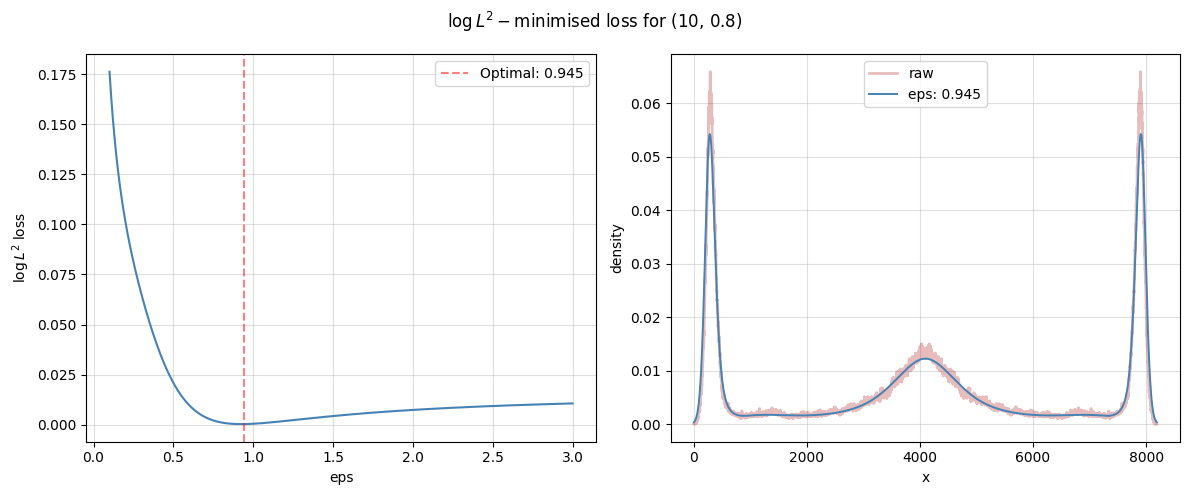

In [ ]:
plt.figure(figsize=(12, 5))
fig_name = "eps_logL2_fit_w6_Ca0.4"

plt.subplot(1,2,1)
plt.plot(eps_grid, losses, color="steelblue")
plt.axvline(eps_opt_logL2, color="r", linestyle="--", alpha=0.5, label=f"Optimal: {eps_opt_logL2:.3f}")
plt.xlabel("eps")
plt.ylabel("$\log L^2$ loss")
plt.legend()
plt.grid(alpha=0.4)

plt.subplot(1,2,2)
plt.plot(p_raw, lw=2.0, color="firebrick", label="raw",alpha=0.3)
plt.plot(p_spline_opt, lw=1.4, color="steelblue", label=f"eps: {eps_opt_logL2:.3f}")
#plt.plot(p_spline_eps, lw=1.4, color="steelblue", label=f"eps: {eps_c}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.4)

plt.suptitle(f"$\log L^2-$minimised loss for {key}")
plt.tight_layout()
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

## Attempting to fit epsilon on full data set

$L^2$ and $L^\infty-\text{norms}$ seem to give the best results, but the latter seems a bit rougher, so we use the more standard choice - the former.

In [ ]:
def implied_pdf_from_V_eps(V, x, eps=1.0):
  dx = x[1] - x[0]
  p = np.exp(-V / eps)
  p /= np.sum(p) * dx
  return p


def loss_L2(x, p_model, p_raw):
  dx = x[1] - x[0]
  return np.sum((p_model - p_raw)**2) * dx


def fit_eps_Vspline_by_loss(x, Vspline, p_raw, eps_grid, loss_fn):
  dx = x[1] - x[0]
  p_raw = p_raw / (np.sum(p_raw) * dx) # just making sure
  losses = np.empty_like(eps_grid, dtype=np.float64)

  for k, eps in enumerate(eps_grid):
    p_model = implied_pdf_from_V_eps(Vspline, x, eps)
    losses[k] = loss_fn(x, p_model, p_raw)

  eps_opt = eps_grid[np.argmin(losses)]
  return losses, eps_opt

In [ ]:
eps_c = 0.85
eps_grid = np.linspace(0.1, 3, 3100)

loss_dic = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    x = recon_pdfs_raw[key]["bin_centres"]
    p_raw = recon_pdfs_raw[key]["density"]
    V = tables_spline[key]["V"]

    p_spline_eps = implied_pdf_from_V_eps(V, x, eps_c)
    losses, eps_opt_L2 = fit_eps_Vspline_by_loss(x, V, p_raw, eps_grid, loss_L2)
    p_spline_opt = implied_pdf_from_V_eps(V, x, eps_opt_L2)

    loss_dic[key] = {
        "losses": losses,
        "eps_grid": eps_grid,
        "eps_opt": eps_opt_L2}

## Fitting epsilon plots

<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2365066968.py:31: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("$\epsilon$")


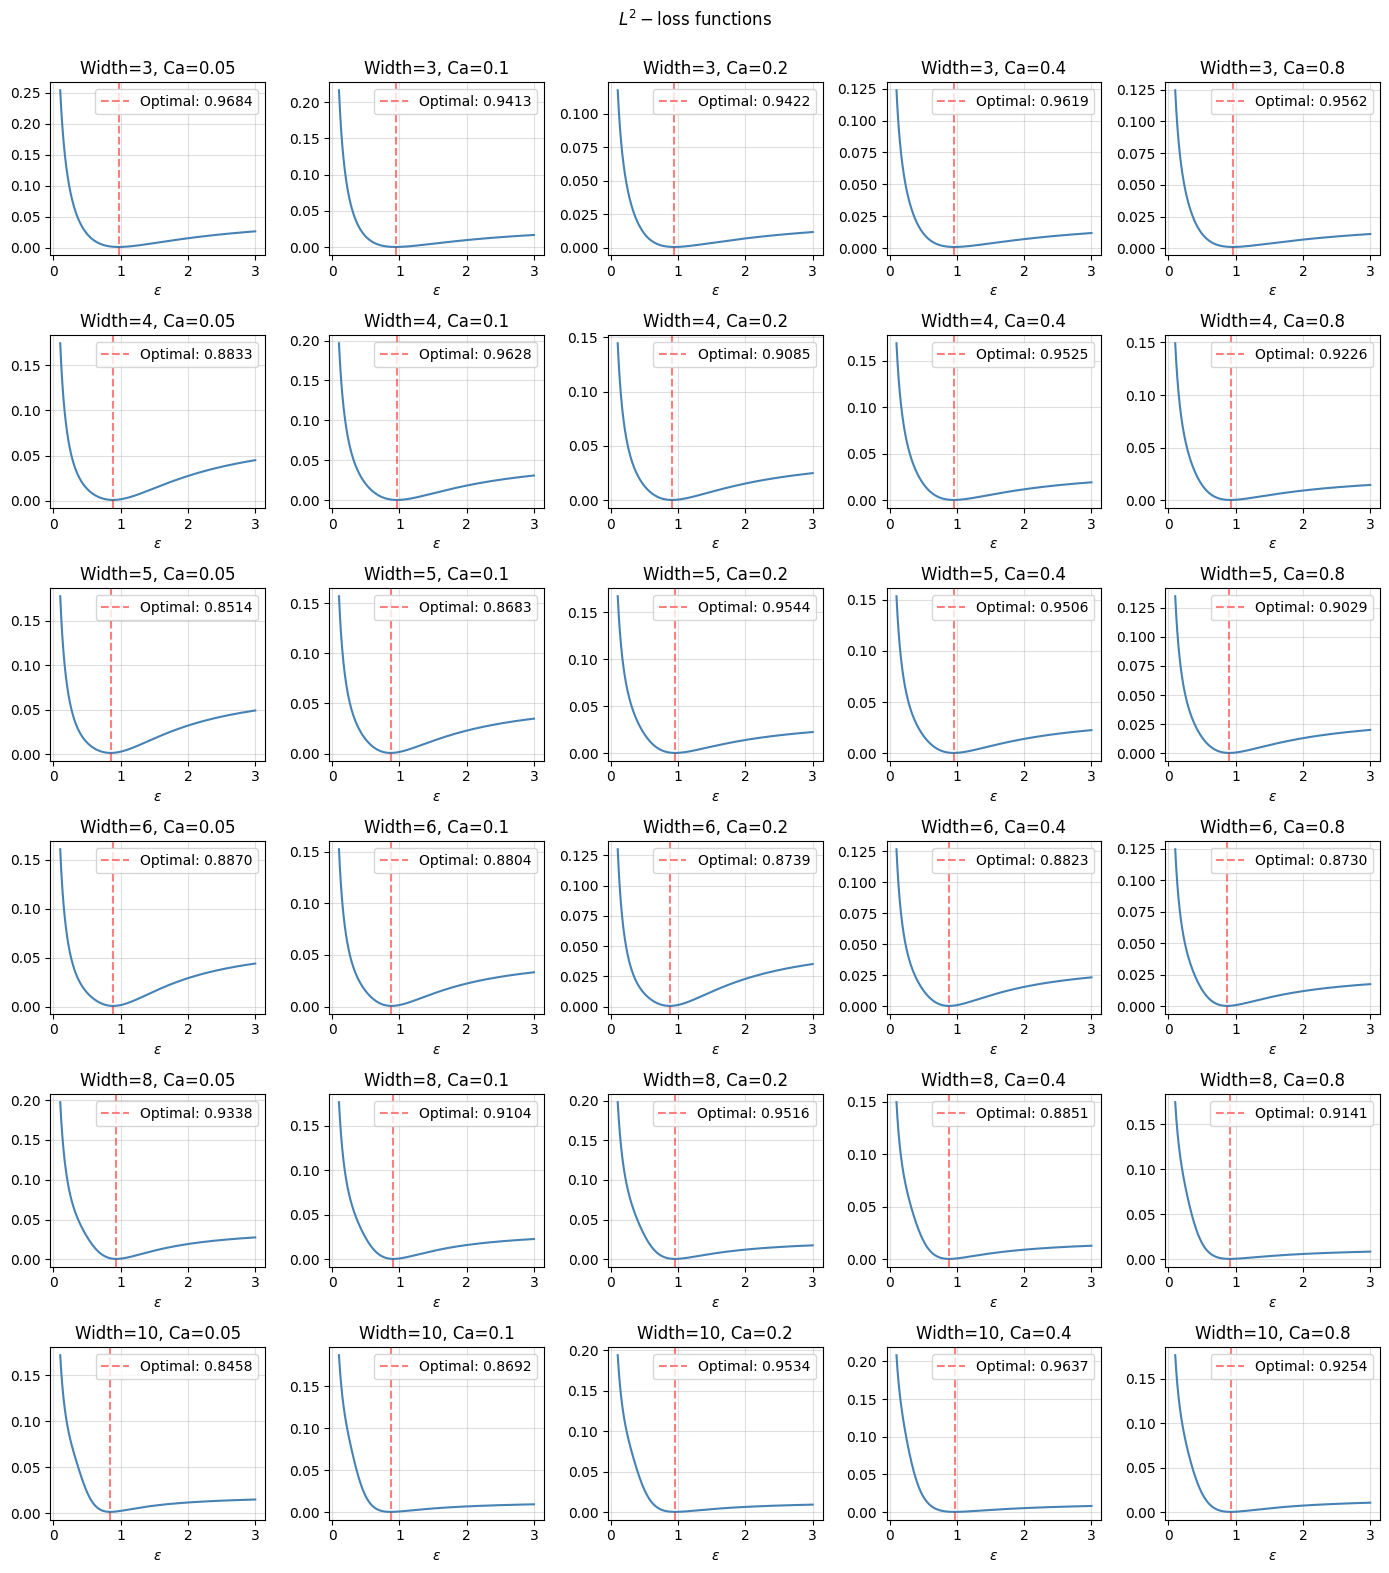

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False)

fig_name = "loss_L2_all"

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset_spline = tables_spline[key]
    subset_raw = recon_pdfs_raw[key]
    subset_eps = loss_dic[key]

    eps_opt = subset_eps["eps_opt"]
    eps_grid = subset_eps["eps_grid"]
    losses = subset_eps["losses"]

    old_dens = subset_raw["density"]
    x = subset_spline["x"]
    V_spline = subset_spline["V"]
    density = implied_pdf_from_V_eps(V_spline, x, eps=eps_opt)


    # Plotting
    ax.plot(eps_grid, losses, color="steelblue")
    ax.axvline(eps_opt, color="r", linestyle="--", alpha=0.5, label=f"Optimal: {eps_opt:.4f}")
    ax.set_xlabel("$\epsilon$")
    ax.set_title(f"Width={w}, Ca={Ca}")
    ax.legend()
    ax.grid(alpha=0.4)

    # Stats
    #dx = x[1] - x[0]
    #L1 = np.sum(np.abs(density - old_dens))
    #L2 = np.sqrt(np.sum((density - old_dens)**2) * dx)
    #Linf = np.max(np.abs(density - old_dens))
    #stats_text = (
    #    f"$L^1$ = {L1:.3e}\n"
    #    f"$L^2$ = {L2:.3e}\n"
    #    f"$L^\\infty$ = {Linf:.3e}\n"
    #    f"Area = {np.sum(density * dx):.3f}")

    #y_align=0.95
    #ax.text(0.5, y_align, stats_text, transform=ax.transAxes,
    #        horizontalalignment="center", verticalalignment="top", fontsize=9,
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("$L^2-$loss functions")
plt.tight_layout(rect=[0, 0, 1, .98])
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2099185384.py:28: SyntaxWarning: invalid escape sequence '\e'
  label=f"$\epsilon=${eps_opt:.3f}")


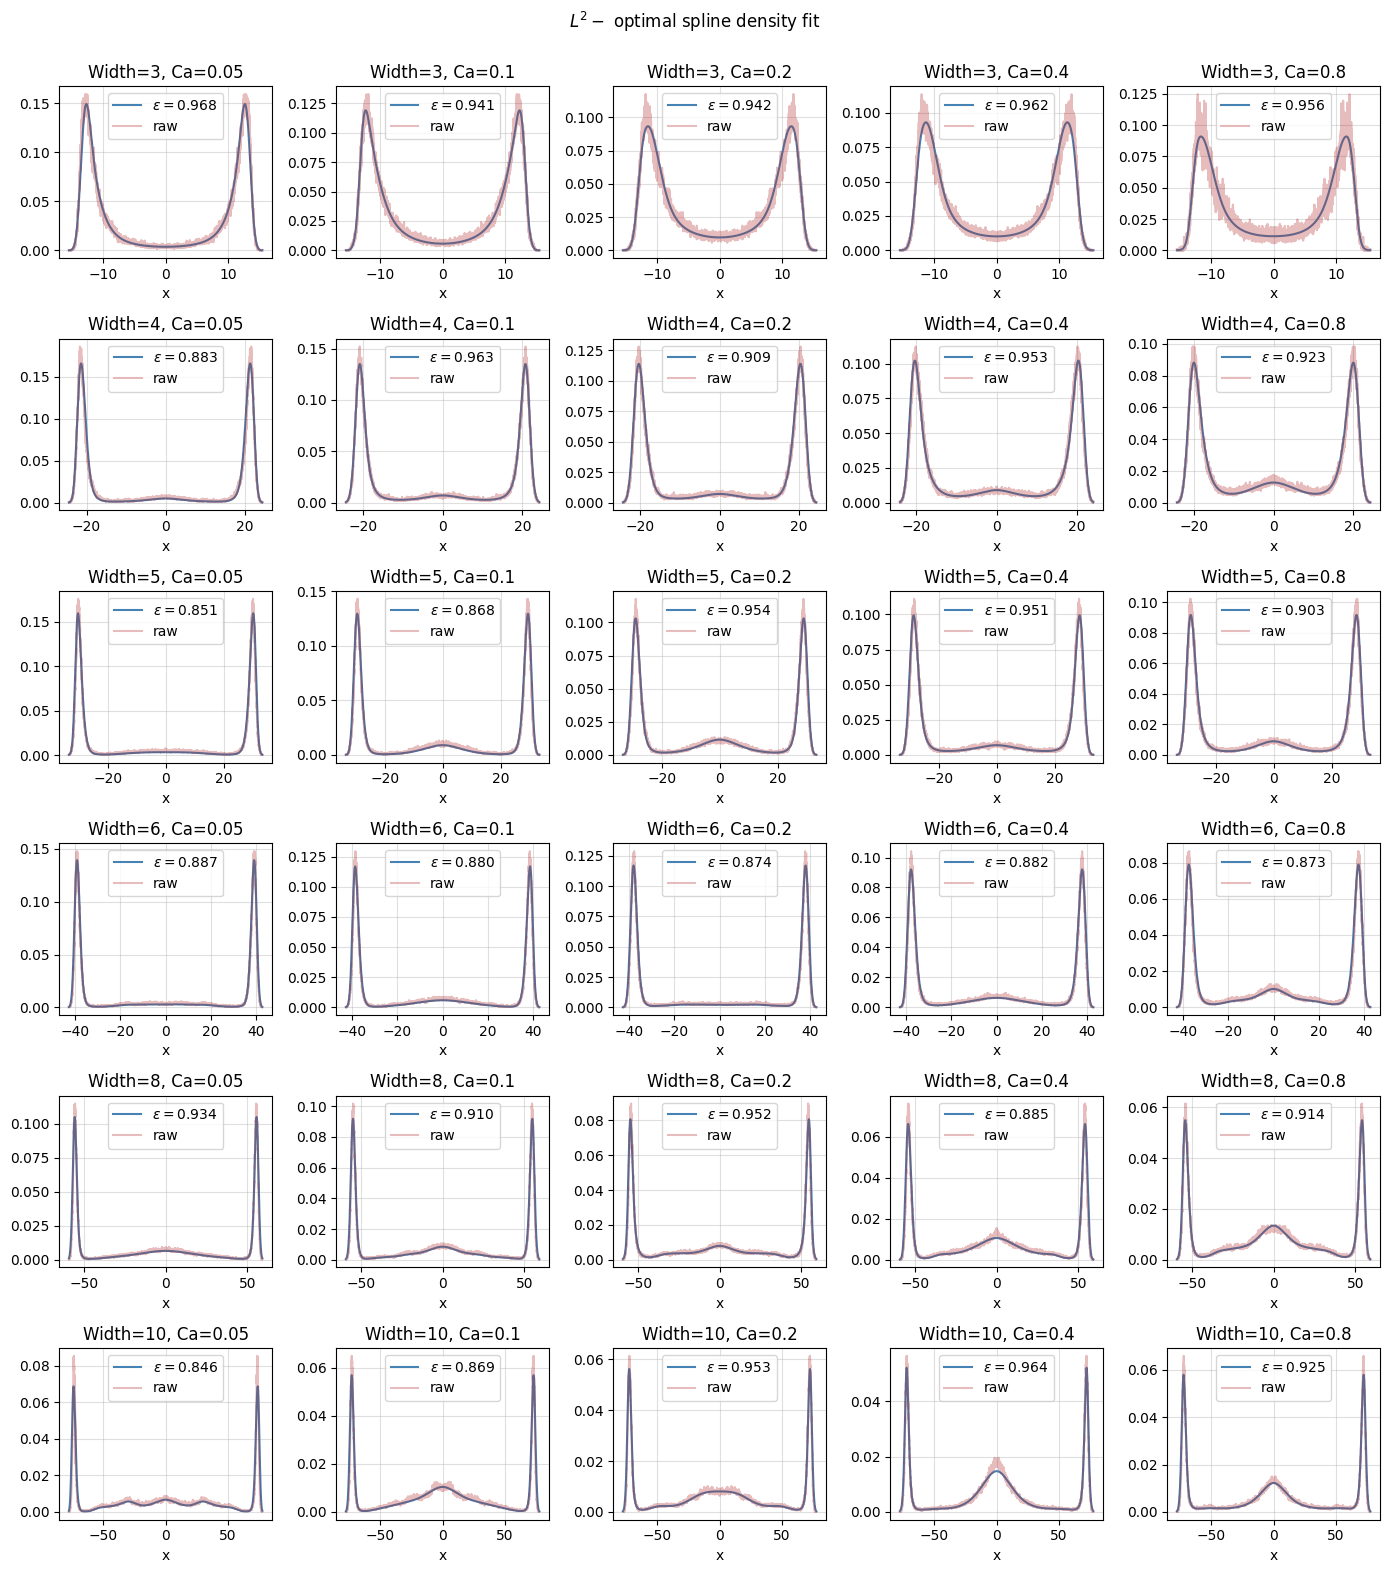

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False)

fig_name = "optimal_splines"

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset_spline = tables_spline[key]
    subset_raw = recon_pdfs_raw[key]
    subset_eps = loss_dic[key]

    eps_opt = subset_eps["eps_opt"]

    old_dens = subset_raw["density"]
    x = subset_spline["x"]
    V_spline = subset_spline["V"]
    density = implied_pdf_from_V_eps(V_spline, x, eps=eps_opt)


    # Plotting
    ax.plot(x, density, color="steelblue",
            label=f"$\epsilon=${eps_opt:.3f}")
    ax.plot(x, old_dens, color="firebrick", alpha=0.3, label="raw")
    ax.set_xlabel("x")
    #ax.set_ylabel("density")
    ax.set_title(f"Width={w}, Ca={Ca}")
    ax.legend()
    ax.grid(alpha=0.4)

    # Stats
    #dx = x[1] - x[0]
    #L1 = np.sum(np.abs(density - old_dens))
    #L2 = np.sqrt(np.sum((density - old_dens)**2) * dx)
    #Linf = np.max(np.abs(density - old_dens))
    #stats_text = (
    #    f"$L^1$ = {L1:.3e}\n"
    #    f"$L^2$ = {L2:.3e}\n"
    #    f"$L^\\infty$ = {Linf:.3e}\n"
    #    f"Area = {np.sum(density * dx):.3f}")

    #y_align=0.95
    #ax.text(0.5, y_align, stats_text, transform=ax.transAxes,
    #        horizontalalignment="center", verticalalignment="top", fontsize=9,
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("$L^2-$ optimal spline density fit")
plt.tight_layout(rect=[0, 0, 1, .98])
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

# Save optimal spline fits

In [ ]:
#raise(BufferError("Saving"))

for w in widths:
  for Ca in CaArr:
    save_path = base_dir + f"/PDFs/Splines/splines_w{w}_Ca{Ca}.npz"
    key = (w, Ca)
    subset = tables_spline[key]

    x = subset["x"]
    V = subset["V"]
    F = subset["F"]
    eps = loss_dic[key]["eps_opt"]

    pdf = implied_pdf_from_V_eps(V, x, eps=eps)

    np.savez(save_path,
             x = x,
             density = pdf,
             potential = V,
             force = F,
             eps = eps)

# Extract Kramers' times from spline approximations

## Set-up

### Finding wells/barriers

In [ ]:
def find_outer_wells(V, x):
  mins = np.where((V[1:-1] < V[:-2]) & (V[1:-1] < V[2:]))[0] + 1
  if len(mins) < 2:
    raise ValueError("Not enough minima detected")

  # pick the two deepest wells
  mins = mins[np.argsort(V[mins])[:2]]

  # order left to right
  mins = mins[np.argsort(x[mins])]
  return mins[0], mins[1]


def find_outer_barriers(V, x, iL, iR):
  iC = np.argmin(np.abs(x))

  if not (iL < iC < iR):
    raise ValueError("Incorrect well ordering")

  iB_L = iL + np.argmax(V[iL:iC+1])
  iB_R = iC + np.argmax(V[iC:iR])

  return iB_L, iB_R

In [ ]:
outer_wells = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = tables_spline[key]

    x = subset["x"]
    V = subset["V"]

    iL, iR = find_outer_wells(V, x)

    outer_wells[key] = {
        "well_L": x[iL],
        "well_R": x[iR],
        "well_L_idx": iL,
        "well_R_idx": iR}

In [ ]:
highest_barriers = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = tables_spline[key]

    x = subset["x"]
    V = subset["V"]

    iL, iR = find_outer_wells(V, x)
    iB_L, iB_R = find_outer_barriers(V, x, iL, iR)

    highest_barriers[key] = {
        "barrier_L": x[iB_L],
        "barrier_R": x[iB_R],
        "barrier_L_idx": iB_L,
        "barrier_R_idx": iB_R}

## Sanity check plot

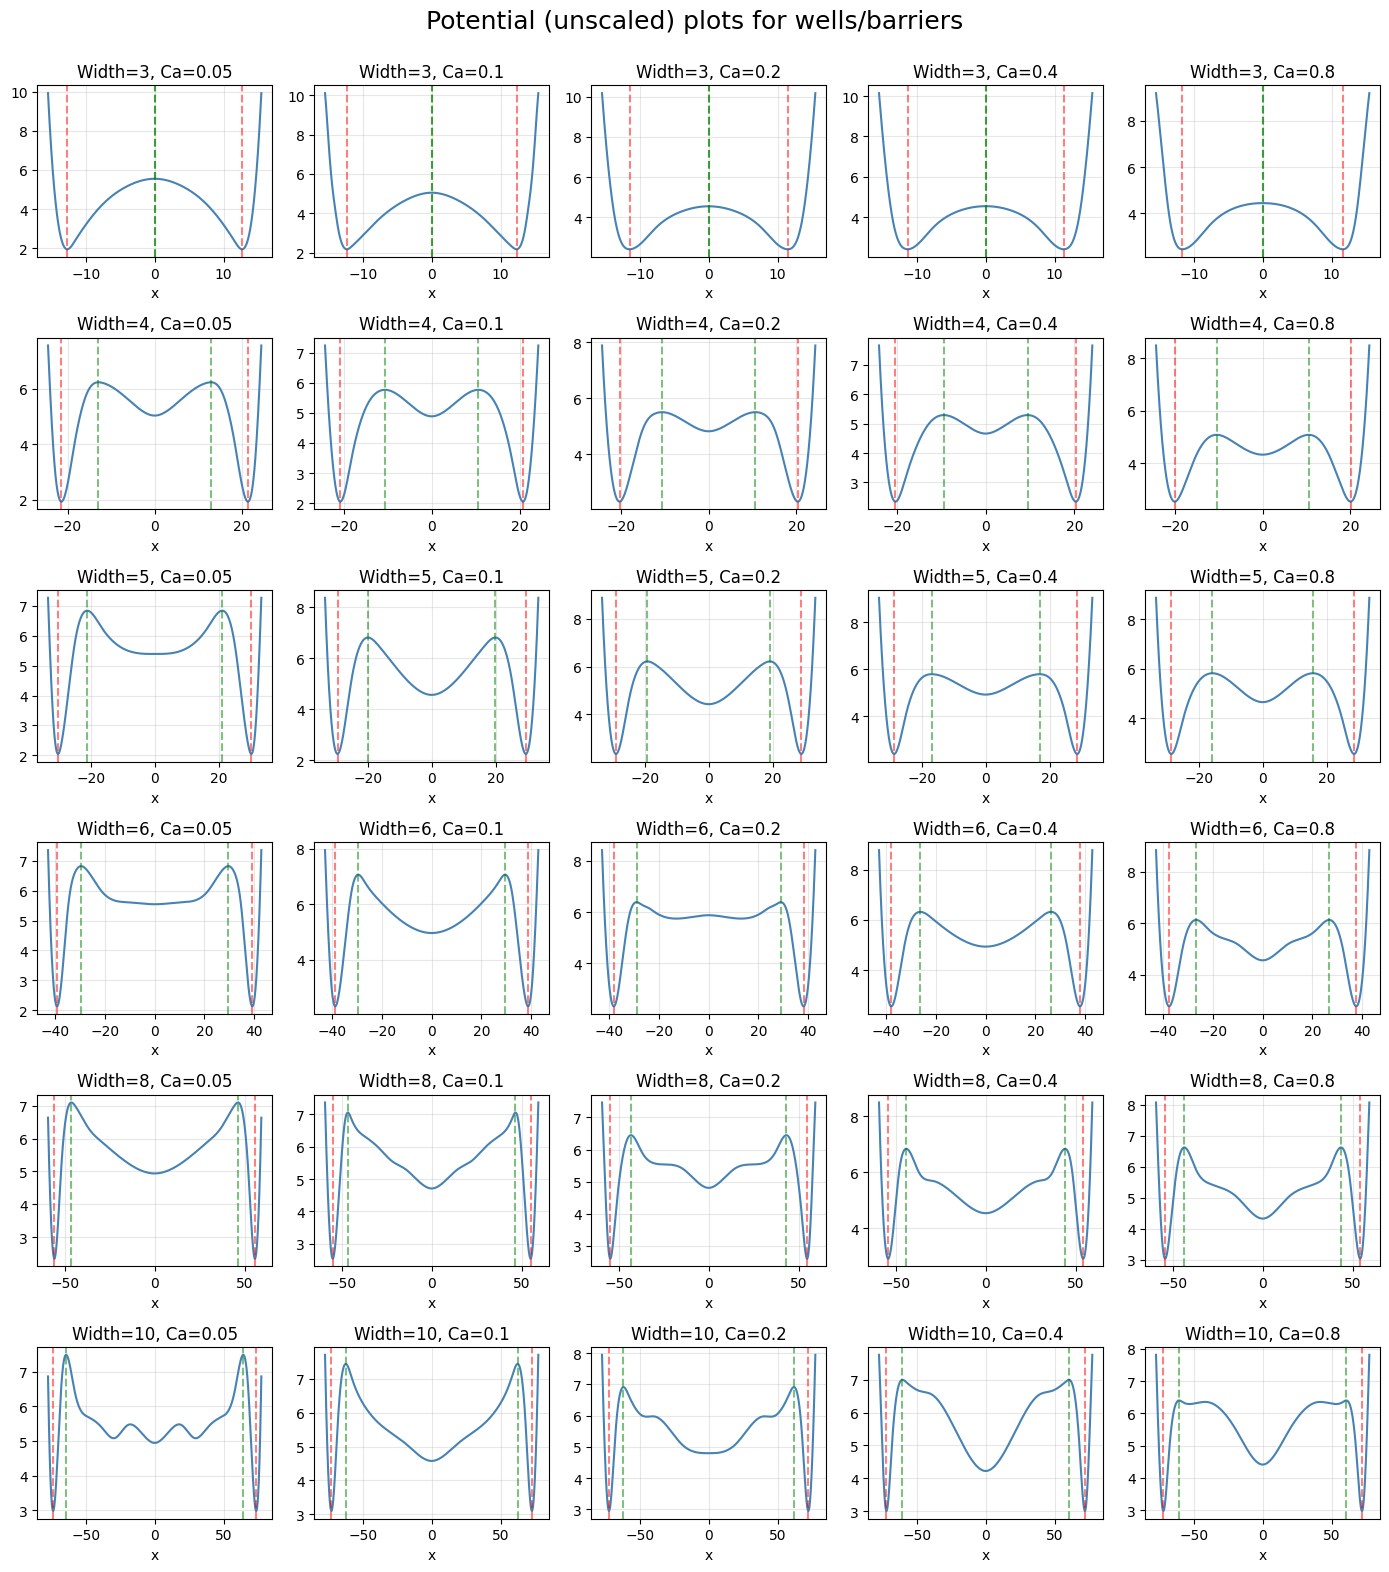

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False
)

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset = tables_spline[key]
    wells = outer_wells[key]
    barriers = highest_barriers[key]

    x = subset["x"]
    V = subset["V"]


    # Plotting
    ax.plot(x, V, color="steelblue")
    ax.axvline(wells["well_L"], color="r", linestyle="--", alpha=0.5)
    ax.axvline(wells["well_R"], color="r", linestyle="--", alpha=0.5)
    ax.axvline(barriers["barrier_L"],
               color="g", linestyle="--", alpha=0.5)
    ax.axvline(barriers["barrier_R"],
               color="g", linestyle="--", alpha=0.5)

    ax.set_title(f"Width={w}, Ca={Ca}")
    ax.set_xlabel('x')
    #ax.legend()
    ax.grid(True, alpha=0.3)

    y_align=0.12

    #stats_text = f"Lorem ipsum"
    #ax.text(0.5, y_align, stats_text, transform=ax.transAxes,
    #        horizontalalignment="center", verticalalignment="top", fontsize=9,
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Potential (unscaled) plots for wells/barriers", y=0.98, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, .98])
plt.show()

### Finding statistically motivated barrier tolerances

$$
\mathbb{P}[\text{climb potential gap } \Delta V] \approx e^{-\Delta V/\varepsilon}\\
\Delta V \approx -\varepsilon \log(p) \\
\text{For probability 1e-3:}\\
\Delta V \approx 6.9078\varepsilon
$$

So, we will use $(k\cdot\varepsilon)$ as our barrier tolerance.

In [ ]:
# \mathbb{P}[climb potential gap \Delta V] \approx e^{-\Delta V/eps}
# \Delta V \approx -eps log(p)

confidence = 0.33
deltaV_by_eps = -np.log(confidence)
print(deltaV_by_eps)

1.1086626245216111


Attempted above method but did not work nicely. Probability requested is either dysfunctionally high, or requires non-integer values, which defeats the purpose of tolerances being nicely "informed".

Instead, we inform our tolerances via the curvature of the splined potentials.

In [ ]:
tol_dic = {}
c = 1.0   # width multiplier

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)

    eps = loss_dic[key]["eps_opt"]
    x = tables_spline[key]["x"]
    V = tables_spline[key]["V"]
    F = tables_spline[key]["F"]
    S = np.gradient(F, x)

    iB_L = highest_barriers[key]["barrier_L_idx"]
    iB_R = highest_barriers[key]["barrier_R_idx"]

    # --- Left barrier ---
    curv_L = abs(S[iB_L])
    sigma_L = np.sqrt(eps / curv_L)

    tol_Ll = x[iB_L] - c * sigma_L
    tol_Lr = x[iB_L] + c * sigma_L

    # --- Right barrier ---
    curv_R = abs(S[iB_R])
    sigma_R = np.sqrt(eps / curv_R)

    tol_Rl = x[iB_R] - c * sigma_R
    tol_Rr = x[iB_R] + c * sigma_R

    tol_dic[key] = {
        "tol_Ll": tol_Ll,
        "tol_Lr": tol_Lr,
        "tol_Rl": tol_Rl,
        "tol_Rr": tol_Rr,
        "sigma_L": sigma_L,
        "sigma_R": sigma_R}

In [ ]:
def save_nested_dic(path, dic):
  flat = {}
  for (w, Ca), sub in dic.items():
    for field, val in sub.items():
      flat[f"{w}__{Ca}__{field}"] = np.asarray(val)
  np.savez(path, **flat)

def save_scalar_dic(path, dic, name="value"):
  with open(path, "w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["w", "Ca", name])
    for (w, Ca), val in sorted(dic.items()):
      wr.writerow([w, Ca, float(val)])

In [ ]:
raise BufferError("Saving!")

save_nested_dic(base_dir + "/PDFs/tolerances.npz", tol_dic)
save_nested_dic(base_dir + "/PDFs/wells.npz", outer_wells)

In [ ]:
#raise BufferError("Overwriting/loading tol_dic, well_dic")

def load_nested_dic(path):
  raw = np.load(path)
  dic = {}
  for k in raw.files:
    w, Ca, field = k.split("__", 2)
    dic.setdefault((int(w), float(Ca)), {})[field] = raw[k].item()
  return dic

def load_scalar_dic(path):
  dic = {}
  with open(path, newline="") as f:
    rd = csv.DictReader(f)
    val_col = rd.fieldnames[2]
    for row in rd:
      dic[(int(row["w"]), float(row["Ca"]))] = float(row[val_col])
  return dic

tol_dic   = load_nested_dic(base_dir + "/PDFs/tolerances.npz")
well_dic  = load_nested_dic(base_dir + "/PDFs/wells.npz")

### Check barriers plot

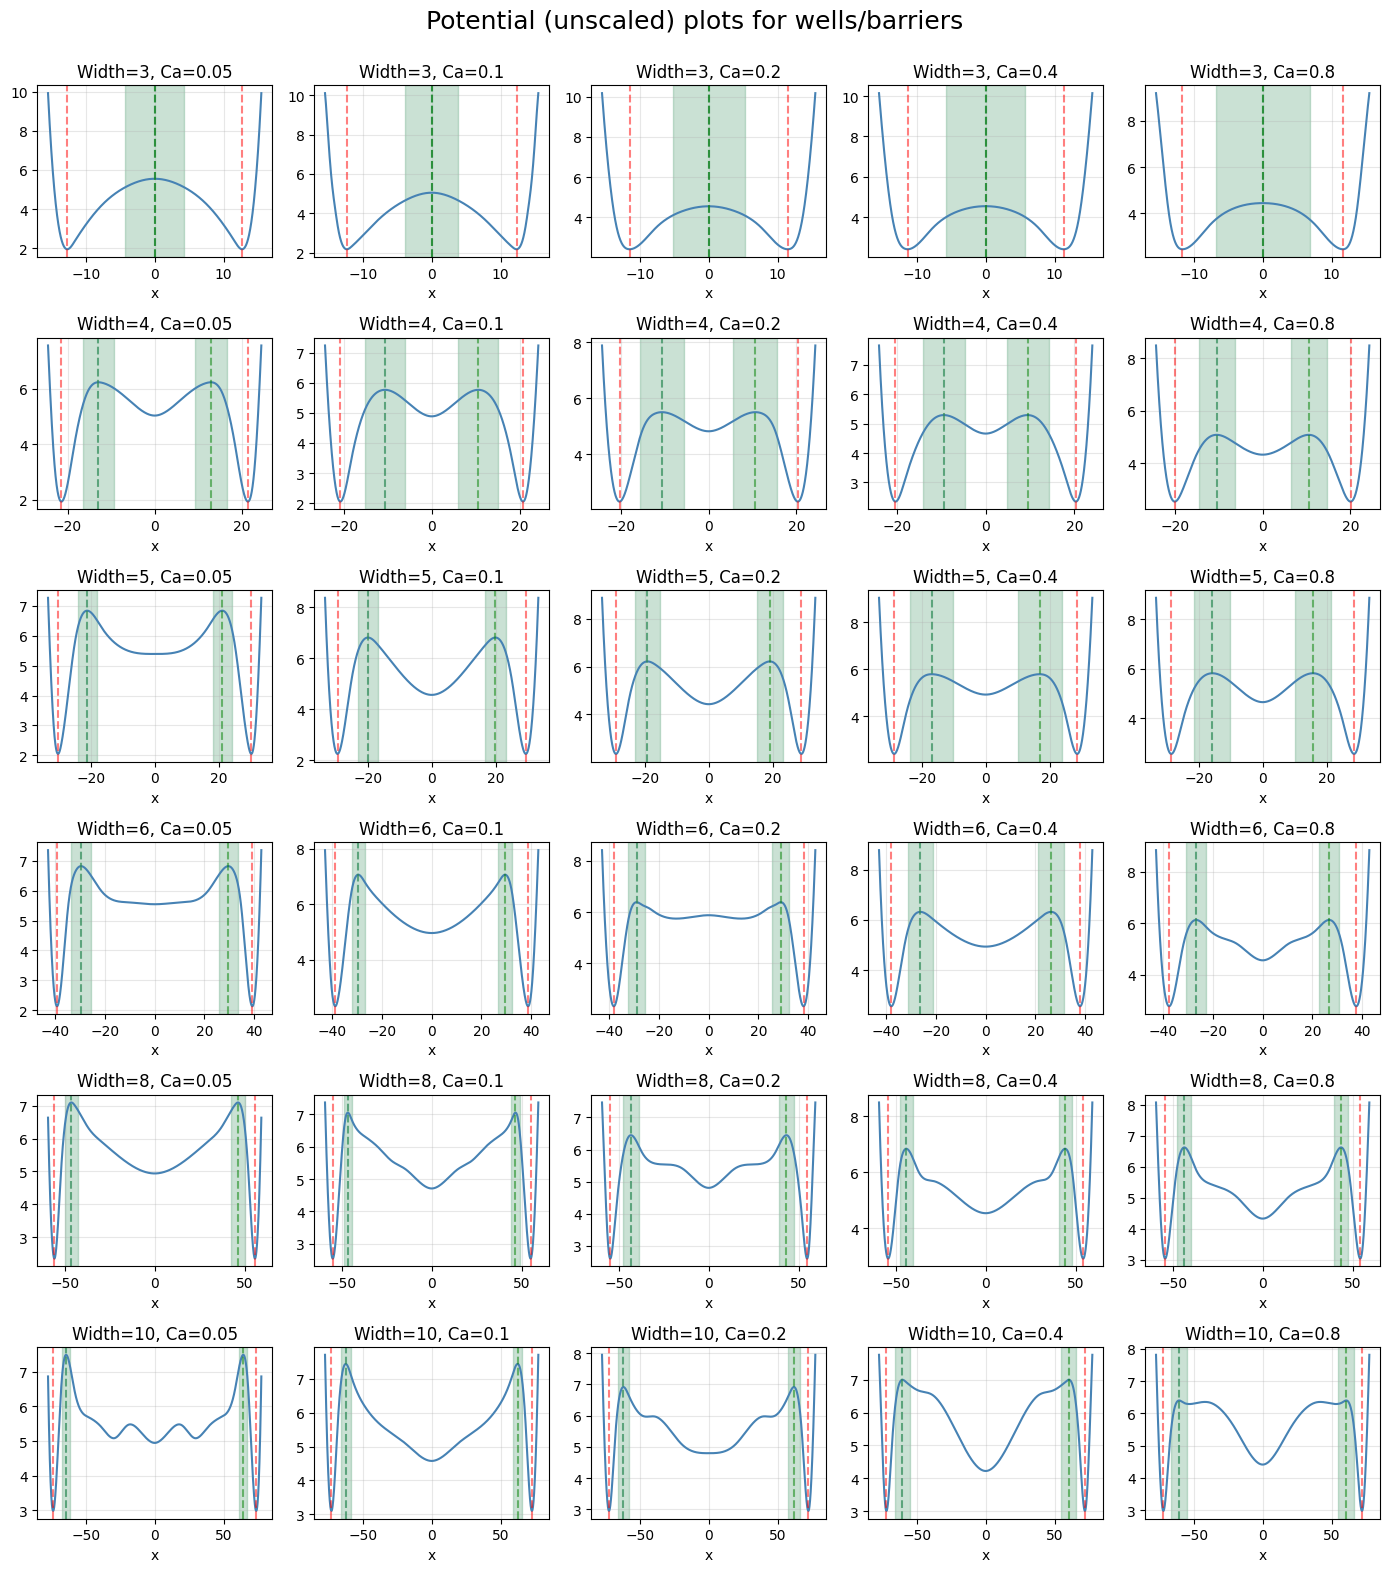

In [ ]:
fig, axes = plt.subplots(
    nrows = len(widths),
    ncols = len(CaArr),
    figsize = (14, 16),
    sharex=False, #important, else plots look ugly
    sharey=False
)

for i, w in enumerate(widths):
  for j, Ca in enumerate(CaArr):
    ax = axes[i, j]
    key = (w, Ca)
    subset = tables_spline[key]
    wells = outer_wells[key]
    barriers = highest_barriers[key]

    tols = tol_dic[key]

    V = subset["V"]
    x = subset["x"]
    dx = subset["dx"]


    # Plotting
    ax.plot(x, V, color="steelblue")
    ax.axvline(wells["well_L"], color="r", linestyle="--", alpha=0.5)
    ax.axvline(wells["well_R"], color="r", linestyle="--", alpha=0.5)
    ax.axvline(barriers["barrier_L"],
               color="seagreen", linestyle="--", alpha=0.7)
    ax.axvline(barriers["barrier_R"],
               color="g", linestyle="--", alpha=0.5)

    # Left barrier region
    ax.axvspan(tols["tol_Ll"], tols["tol_Lr"], color="seagreen", alpha=0.25)

    # Right barrier region
    if w != 3:
      ax.axvspan(tols["tol_Rl"], tols["tol_Rr"], color="seagreen", alpha=0.25)

    ax.set_title(f"Width={w}, Ca={Ca}")
    ax.set_xlabel('x')
    #ax.legend()
    ax.grid(True, alpha=0.3)

    y_align=0.12

    #stats_text = f"Lorem ipsum"
    #ax.text(0.5, y_align, stats_text, transform=ax.transAxes,
    #        horizontalalignment="center", verticalalignment="top", fontsize=9,
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Potential (unscaled) plots for wells/barriers", y=0.98, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, .98])
plt.show()

## Kramers time

In [ ]:
def kramers_by_idx(V, x, well_idx, barrier_idx, eps=1.0):
  F = np.gradient(V, x)
  S = np.gradient(F, x)

  curv_min = S[well_idx]
  curv_max = S[barrier_idx]

  dV = (V[barrier_idx] - V[well_idx]) / eps

  return (2*np.pi)/(np.sqrt(np.abs(curv_max * curv_min))) * np.exp(dV)

In [ ]:
kramers_OtO = {}  # direct only?
kramers_OtI = {}
kramers_ItO = {}

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    subset = tables_spline[key]
    wells = outer_wells[key]
    barriers = highest_barriers[key]

    V = subset["V"]
    x = subset["x"]
    eps = loss_dic[key]["eps_opt"]

    wL_idx = wells["well_L_idx"]
    wR_idx = wells["well_R_idx"]
    wC_idx = np.argmin(np.abs(x))
    bL_idx = barriers["barrier_L_idx"]
    bR_idx = barriers["barrier_R_idx"]

    # by symmetry, only need LC, CL
    t_LC = kramers_by_idx(V, x, wL_idx, bL_idx, eps)
    t_CL = kramers_by_idx(V, x, wC_idx, bL_idx, eps)

    k_LC = 1/t_LC
    k_CL = 1/t_CL

    t_OtI = 1/(k_LC)
    t_ItO = 1/(k_CL)
    t_OtO = 2/(k_LC) + 1/(k_CL)

    kramers_OtI[key] = t_OtI
    kramers_ItO[key] = t_ItO
    kramers_OtO[key] = t_OtO

In [ ]:
key = (6, 0.4)

print("Kramers MFPTs:")
print("OtI: ", kramers_OtI[key])
print("ItO: ", kramers_ItO[key])
print("OtO: ", kramers_OtO[key])

Kramers MFPTs:
OtI:  4017.600761062954
ItO:  1103.4009111016244
OtO:  9138.602433227532
